In [12]:
import scanpy as sc
import spice
import pandas as pd  
import anndata as ad
import numpy as np
import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42   
matplotlib.rcParams["ps.fonttype"]  = 42  
import matplotlib.pyplot as plt


In [2]:
#read in adata
adata = ad.read_h5ad("adata_example.h5ad")
adata

AnnData object with n_obs × n_vars = 164000 × 0
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'dataset', 'celltype_major', 'celltype_minor', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden', 'B cells Memory', 'B cells Naive', 'CAFs MSC iCAF-like', 'CAFs myCAF-like', 'Cancer Basal SC', 'Cancer Cycling', 'Cancer Her2 SC', 'Cancer LumA SC', 'Cancer LumB SC', 'Cycling PVL', 'Cycling T-cells', 'Cycling_Myeloid', 'DCs', 'Endothelial ACKR1', 'Endothelial CXCL12', 'Endothelial Lymphatic LYVE1', 'Endothelial RGS5', 'Luminal Progenitors', 'Macrophage', 'Mature Luminal', 'Monocyte', 'Myoepithelial', 'NK cells', 'NKT cells', 'PVL Differentiated', 'PVL Immature', 'Plasmablasts', 'T cells CD4+', 'T cells CD8+', 'batch', 'array_row', 'array_

In [3]:
spice.tl.assign_state_labels(
    adata,
    score_key="EMT_hallmarks_tumour", # column in adata.obs with the continuous score
    n_states=4, # 2 (median split) or 4 (quartile split)
    tumour_mask_key="cancer_epithelial_label", # only label tumour cells; None labels all cells
    label_key="state_label", # destination column in adata.obs
)

In [4]:
spice.tl.build_graph(
    adata,
    spatial_key="spatial", # key in adata.obsm
    n_neighbors=12, # number of nearest neighbors
    celltype_key="celltype_minor", # cell-type column in adata.obs
    label_key="state_label", # labels from step 1
    score_key="state_label", # continuous score (stored as node attribute)
    n_blocks=4, # grid divisions for spatial block assignment
)

Example running using just cell type

In [ ]:
spice.tl.cross_validate(
    adata,
    feature_mode="celltype", # "celltype", "intrinsic" or "combined"
    num_folds=3,
    num_epochs=500,
    hidden_dim1=16,
    hidden_dim2=32,
    dropout=0.5,
    learning_rate=0.01,
    class_weights=True, # inverse-frequency weighting
    inductive_split=True, # spatial block split (True) or random node split (False)
    return_last=True, # use last epoch's predictions
    verbose=True)


Fold 1/3
  Epoch    0 | Loss 0.3448 | Test AUC: 0.5451
  Epoch    4 | Loss 0.3426 | Test AUC: 0.5953

Fold 2/3
  Epoch    0 | Loss 0.3491 | Test AUC: 0.5952
  Epoch    4 | Loss 0.3457 | Test AUC: 0.5889

Fold 3/3
  Epoch    0 | Loss 0.3470 | Test AUC: 0.5719
  Epoch    4 | Loss 0.3446 | Test AUC: 0.5872

Mean performance: 0.5926 ± 0.0038


Example running intrinsic and extrinsic

In [6]:
spice.tl.cross_validate(
    adata,
    feature_mode="combined", # "celltype", "intrinsic" or "combined"
    num_folds=5,
    num_epochs=500,
    hidden_dim1=16,
    hidden_dim2=32,
    dropout=0.5,
    learning_rate=0.01,
    class_weights=True, # inverse-frequency weighting
    inductive_split=True, # spatial block split (True) or random node split (False)
    return_last=True, # use last epoch's predictions
    verbose=True,
    pca_key="PCs",
    n_pcs=7
)


Fold 1/5
  Epoch    0 | Loss 0.3471 | Test AUC: 0.4959
  Epoch  100 | Loss 0.3222 | Test AUC: 0.6238
  Epoch  200 | Loss 0.3200 | Test AUC: 0.6259
  Epoch  300 | Loss 0.3193 | Test AUC: 0.6279
  Epoch  400 | Loss 0.3183 | Test AUC: 0.6283
  Epoch  499 | Loss 0.3182 | Test AUC: 0.6289

Fold 2/5
  Epoch    0 | Loss 0.3467 | Test AUC: 0.6261
  Epoch  100 | Loss 0.3262 | Test AUC: 0.6153
  Epoch  200 | Loss 0.3251 | Test AUC: 0.6188
  Epoch  300 | Loss 0.3239 | Test AUC: 0.6167
  Epoch  400 | Loss 0.3237 | Test AUC: 0.6198
  Epoch  499 | Loss 0.3236 | Test AUC: 0.6178

Fold 3/5
  Epoch    0 | Loss 0.3467 | Test AUC: 0.5801
  Epoch  100 | Loss 0.3271 | Test AUC: 0.6686
  Epoch  200 | Loss 0.3260 | Test AUC: 0.6701
  Epoch  300 | Loss 0.3253 | Test AUC: 0.6719
  Epoch  400 | Loss 0.3245 | Test AUC: 0.6730
  Epoch  499 | Loss 0.3241 | Test AUC: 0.6742

Fold 4/5
  Epoch    0 | Loss 0.3476 | Test AUC: 0.5386
  Epoch  100 | Loss 0.3227 | Test AUC: 0.5857
  Epoch  200 | Loss 0.3213 | Test AUC: 0

In [6]:
spice.tl.evaluate(adata)

/Users/eloise/Documents/spice_update/SPiCe/spice/pl.py:448: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


(<Figure size 500x350 with 1 Axes>, <Axes: ylabel='AUC'>)

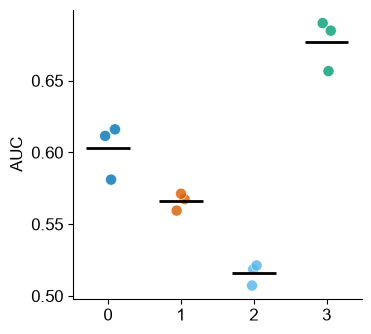

In [7]:
spice.pl.auc_per_class(
    adata,
    state_map={0: "EPI", 1: "H-EPI", 2: "H-MES", 3: "MES"}
)

In [ ]:
spice.tl.explain_nodes(
    adata,
    n_explanations=30,
    ig_steps=25,   
    seed=0,               
)



Computing node explanations for label 3...


Label 3: 100%|██████████| 2/2 [00:09<00:00,  4.51s/it]


Computing node explanations for label 2...


Label 2: 100%|██████████| 2/2 [00:08<00:00,  4.48s/it]


Computing label-shuffled null...


...

Label 0: 100%|██████████| 1/1 [00:04<00:00,  4.51s/it]


Computing label-shuffled null...


Null: 100%|██████████| 2/2 [00:09<00:00,  4.82s/it]


Top node features per label (standardized mean across folds):

  Label 0
            feature      mean  sign_consistency  p_value  q_value
Luminal Progenitors 76.132980               1.0 0.666667 0.987429
     Mature Luminal  8.869269               1.0 0.176967 0.987429
   Endothelial RGS5  3.068551               1.0 0.400000 0.987429
    Cycling_Myeloid  1.888592               1.0 0.400000 0.987429
      Myoepithelial  1.470181               1.0 0.666667 0.987429
    CAFs myCAF-like  0.924022               1.0 0.400000 0.987429
 PVL Differentiated -0.707107               1.0 1.000000 1.000000
       PVL Immature  0.707107               1.0 0.468160 0.987429
    Cycling T-cells  0.707107               1.0 1.000000 1.000000
  Endothelial ACKR1  0.707107               1.0 0.683091 0.987429
 Endothelial CXCL12  0.707107               1.0 0.683091 0.987429
         Macrophage  0.707107               1.0 0.793346 1.000000
       T cells CD8+  0.707107               1.0 0.683091 0.987429
  


/Users/eloise/Documents/spice_update/SPiCe/spice/tl.py:454: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return mannwhitneyu(a, b, alternative="two-sided").pvalue
/Users/eloise/Documents/spice_update/SPiCe/spice/tl.py:454: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return mannwhitneyu(a, b, alternative="two-sided").pvalue
/Users/eloise/Documents/spice_update/SPiCe/spice/tl.py:454: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return mannwhitneyu(a, b, alternative="two-sided").pvalue
/Users/eloise/Documents/spice_update/SPiCe/spice/tl.py:454: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  r

In [ ]:
fig, axes = spice.pl.node_importance_signed(adata, state_map={0: "EPI", 1: "H-EPI", 2: "H-MES", 3: "MES"},save="spice_node_importance_direction.pdf")
plt.show()


In [ ]:
fig, axes = spice.pl.node_importance(adata,state_map={0: "EPI", 1: "H-EPI", 2: "H-MES", 3: "MES"},save="spice_node_importance_no_direction.pdf")
plt.show()


In [ ]:
spice.tl.explain_edges(
    adata,
    n_explanations=50,
    fold_index=0
)

In [ ]:
spice.pl.edge_network(
    adata,
    state_map={0: "EPI", 1: "H-EPI", 2: "H-MES", 3: "MES"},
    alpha=0.05
)

In [ ]:
fig, ax = spice.pl.edge_network(adata, state=0, state_map={0: "EPI"})
